In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py

In [38]:
f = h5py.File("../projects/demo2/parameter-config-2/results.h5", "r")
pd.DataFrame(f["lattice"][0])
f.close()

In [5]:
import toml
import pathlib
project_name = "demo2"
project_path = pathlib.Path("/home/alvaro/Documents/trinity/year4/capstone/capstone-code/projects") / project_name 

params = [x for x in project_path.iterdir() if x.is_dir()]

len(params)

9

In [8]:
import matplotlib.pyplot as plt
fig = plt.figure()
type(fig)

matplotlib.figure.Figure

<Figure size 640x480 with 0 Axes>

In [20]:
import h5py
import numpy as np
import pandas as pd
import toml
import pathlib

# Import lattice matrix
def import_lattice(directory: pathlib.Path, time_step: int) -> pd.DataFrame:
    f = h5py.File(directory / "results.h5", "r")
    lattice = pd.DataFrame(f["lattice"][time_step])
    f.close()
    return lattice
lattice = import_lattice(pathlib.Path("../projects/temperature30_0-3_1-5_l100_dim2/parameter-config-13"), 0)
lattice

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
9995,0.0
9996,0.0
9997,0.0
9998,0.0


In [ ]:
def generate_lattice(time_step:int, df:pd.DataFrame, config:dict) -> np.array:
    L = config["physical_settings"]["L"]
    dim = config["physical_settings"]["dimension"]
    flat_grid = df.to_numpy().flatten()
    shape = tuple([L] * dim)
    full_dim_grid = flat_grid.reshape(shape)
    return full_dim_grid
def import_lattice(directory: pathlib.Path, time_step: int) -> pd.DataFrame:
    f = h5py.File(directory / "results.h5", "r")
    lattice = pd.DataFrame(f["lattice"][time_step])
    f.close()
    return lattice


time_step = 100
df = import_lattice(project_path, time_step)
print(df)
generate_lattice(time_step, df, config)

          0
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
...     ...
999995  0.0
999996  0.0
999997  0.0
999998  0.0
999999  0.0

[1000000 rows x 1 columns]
initial full dim grid shape: (100, 100, 100)


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [2]:
def generate_ising_grid(time_step:int, df:pd.DataFrame):
    ground_1d_grid = df.loc[time_step].to_numpy()[1:]
    ground_grid = np.array([ground_1d_grid[:9]])
    L = 10
    for i in range(1,L):
        a = ground_1d_grid[i*L: i*L + (L-1)]
        ground_grid = np.vstack((ground_grid,a))
    return ground_grid

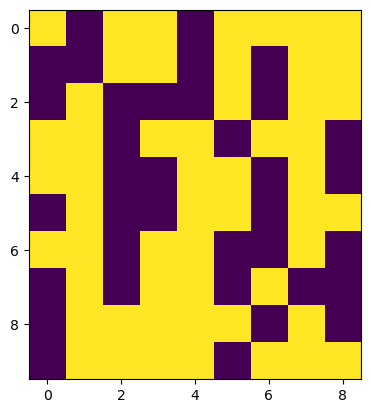

In [14]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
im = ax.imshow(generate_ising_grid(0, df))

def update(frame):
    im.set_array(generate_ising_grid(frame, df))
    return [im]
ani = FuncAnimation(fig, update, frames = 300, interval = 50, blit = True)
html = ani.to_jshtml()
with open("ising_animation.html", "w") as f:
    f.write(html)
ani.save("ising.gif", writer = "pillow", fps = 10)